In [3]:
import os
os.chdir('/Users/' + os.getlogin() + '/Documents/project_1')
print(os.getcwd())

/Users/deno/Documents/project_1


In [4]:
import os
print(os.getcwd())

/Users/deno/Documents/project_1


In [6]:
import pandas as pd

orders = pd.read_csv('data/olist_orders_dataset.csv')
print(orders.shape)
print(orders.head())

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

In [17]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')

print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)

Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)


In [18]:
# Tarihleri düzelt
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Sadece teslim edilmiş siparişler
orders_delivered = orders[orders['order_status'] == 'delivered']

print("Toplam sipariş:", len(orders))
print("Teslim edilen:", len(orders_delivered))

Toplam sipariş: 99441
Teslim edilen: 96478


In [19]:
# Yıl ve ay kolonları oluştur
# dt.to_period('M') → tarihi "2017-10" gibi yıl-ay formatına çevirir
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

# Aylık sipariş sayısını hesapla
# groupby → belirtilen kolona göre grupla
# .size() → her gruptaki satır sayısını say
# .reset_index() → sonucu düzgün bir tabloya çevir
monthly_orders = orders_delivered.groupby('year_month').size().reset_index(name='order_count')

print(monthly_orders)

   year_month  order_count
0     2016-09            1
1     2016-10          265
2     2016-12            1
3     2017-01          750
4     2017-02         1653
5     2017-03         2546
6     2017-04         2303
7     2017-05         3546
8     2017-06         3135
9     2017-07         3872
10    2017-08         4193
11    2017-09         4150
12    2017-10         4478
13    2017-11         7289
14    2017-12         5513
15    2018-01         7069
16    2018-02         6555
17    2018-03         7003
18    2018-04         6798
19    2018-05         6749
20    2018-06         6099
21    2018-07         6159
22    2018-08         6351


/var/folders/72/kv9nywss4pv1gl37mpt0p1nc0000gn/T/ipykernel_10507/2843342578.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')


Matplotlib is building the font cache; this may take a moment.


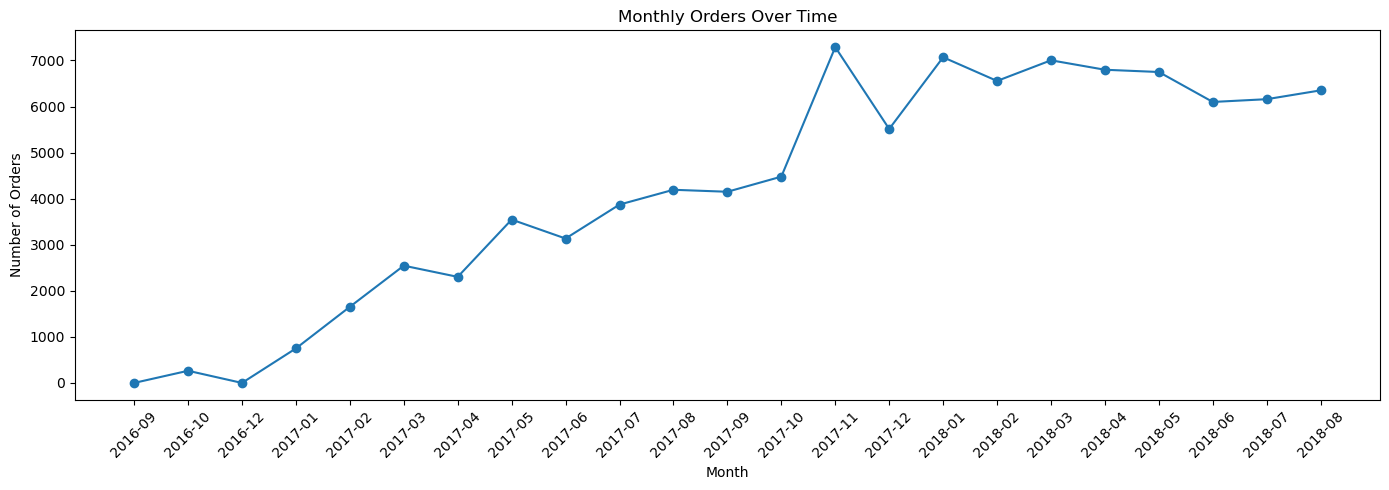

In [20]:
import matplotlib.pyplot as plt

# figure → grafik boyutunu belirler
plt.figure(figsize=(14, 5))

# x ekseni: year_month'u string'e çeviriyoruz (period formatı direkt çizilemiyor)
# y ekseni: order_count
plt.plot(monthly_orders['year_month'].astype(str), monthly_orders['order_count'], marker='o')

# Grafik başlığı ve eksen isimleri
plt.title('Monthly Orders Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

# x eksenindeki yazıların üst üste binmemesi için döndür
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# İki tabloyu birleştir
# merge → SQL'deki JOIN ile aynı şey
# on='order_id' → hangi kolona göre eşleştireceğimizi söylüyoruz
# how='inner' → sadece her iki tabloda da olan order_id'leri al
orders_payments = orders_delivered.merge(payments, on='order_id', how='inner')

# Aylık toplam geliri hesapla
# sum() → size() yerine toplama yapıyor, yani sipariş sayısı değil para topluyor
monthly_revenue = orders_payments.groupby('year_month')['payment_value'].sum().reset_index()

print(monthly_revenue)

   year_month  payment_value
0     2016-10       46566.71
1     2016-12          19.62
2     2017-01      127545.67
3     2017-02      271298.65
4     2017-03      414369.39
5     2017-04      390952.18
6     2017-05      567066.73
7     2017-06      490225.60
8     2017-07      566403.93
9     2017-08      646000.61
10    2017-09      701169.99
11    2017-10      751140.27
12    2017-11     1153528.05
13    2017-12      843199.17
14    2018-01     1078606.86
15    2018-02      966510.88
16    2018-03     1120678.00
17    2018-04     1132933.95
18    2018-05     1128836.69
19    2018-06     1012090.68
20    2018-07     1027903.86
21    2018-08      985414.28


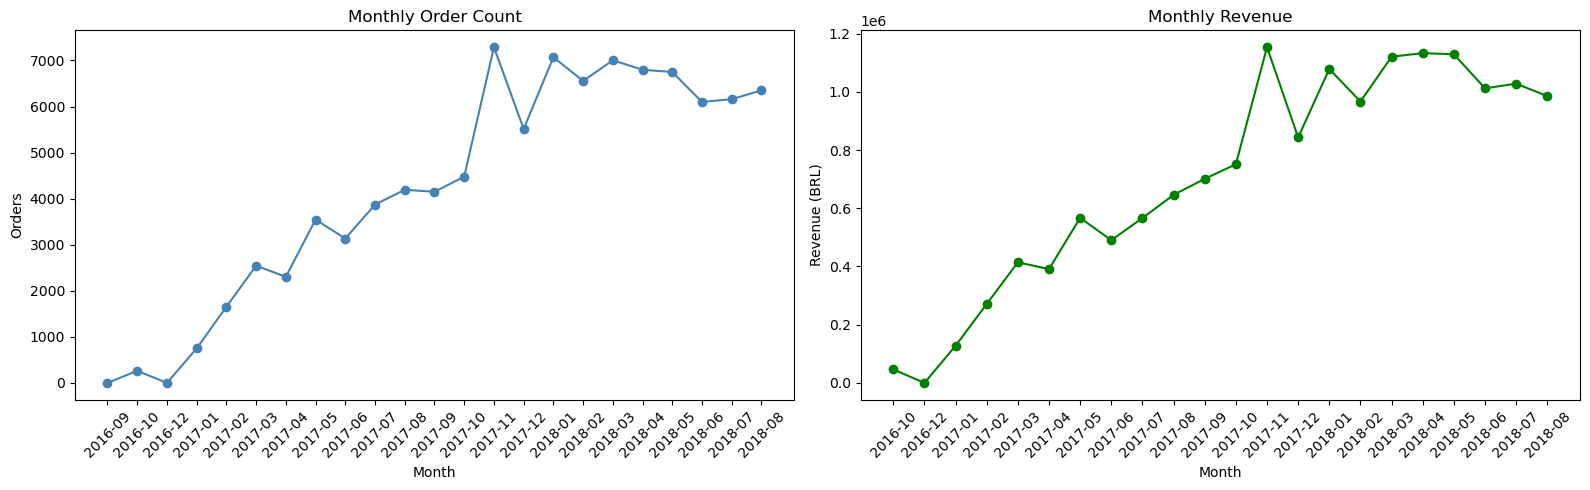

In [22]:
# İki grafiği yan yana koyuyoruz
# plt.subplots(1, 2) → 1 satır, 2 sütun demek
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Sol grafik: sipariş sayısı
ax1.plot(monthly_orders['year_month'].astype(str), monthly_orders['order_count'], marker='o', color='steelblue')
ax1.set_title('Monthly Order Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Orders')
ax1.tick_params(axis='x', rotation=45)

# Sağ grafik: gelir
ax2.plot(monthly_revenue['year_month'].astype(str), monthly_revenue['payment_value'], marker='o', color='green')
ax2.set_title('Monthly Revenue')
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue (BRL)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Ödeme tipine göre grupla
# value_counts() → her değerin kaç kez geçtiğini sayar, büyükten küçüğe sıralar
payment_types = orders_payments['payment_type'].value_counts().reset_index()
payment_types.columns = ['payment_type', 'count']

print(payment_types)

  payment_type  count
0  credit_card  74586
1       boleto  19191
2      voucher   5493
3   debit_card   1486


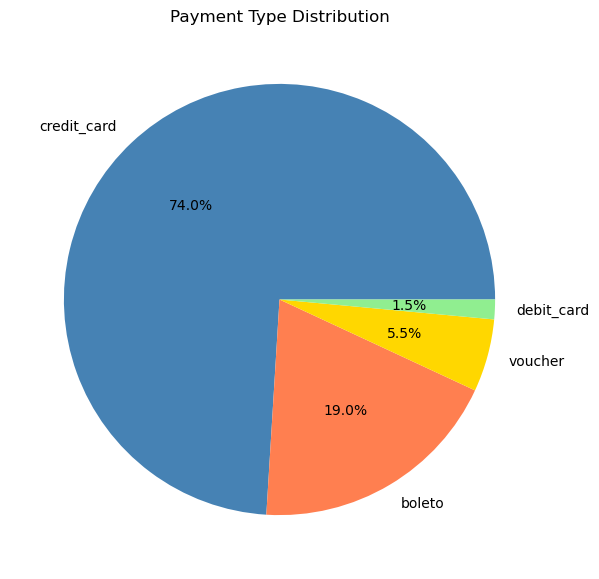

In [24]:
# Pasta grafik
# autopct='%1.1f%%' → her dilimin yüzdesini gösterir
plt.figure(figsize=(7, 7))
plt.pie(payment_types['count'], 
        labels=payment_types['payment_type'], 
        autopct='%1.1f%%',
        colors=['steelblue', 'coral', 'gold', 'lightgreen'])

plt.title('Payment Type Distribution')
plt.show()

In [25]:
# Products ve category translation tablolarını yükle
# Kategori isimleri Portekizce, translation tablosu İngilizce karşılıklarını veriyor
products = pd.read_csv('data/olist_products_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

# Products tablosuna İngilizce kategori isimlerini ekle
# left join → products tablosundaki tüm satırları koru, eşleşen çevirileri ekle
products = products.merge(category_translation, on='product_category_name', how='left')

print(products.shape)
print(products.head(3))

(32951, 10)
                         product_id product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5            perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                 artes   
2  96bd76ec8810374ed1b65e291975717f         esporte_lazer   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  \
0             225.0               16.0               10.0              14.0   
1            1000.0               30.0               18.0              20.0   
2             154.0               18.0                9.0              15.0   

  product_category_name_english  
0                     perfumery  
1                           art  
2                sports_lei

In [26]:
# order_items ile products'ı birleştir
# Böylece her sipariş kaleminin hangi kategoriden olduğunu bileceğiz
order_items_products = order_items.merge(products[['product_id', 'product_category_name_english']], 
                                          on='product_id', how='left')

# Kategoriye göre satış adedi ve toplam gelir hesapla
# agg() → aynı anda birden fazla hesaplama yapmamızı sağlar
category_performance = order_items_products.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),        # kaç sipariş
    total_revenue=('price', 'sum')             # toplam gelir
).reset_index()

# Gelire göre büyükten küçüğe sırala, ilk 10'u al
top10 = category_performance.sort_values('total_revenue', ascending=False).head(10)

print(top10)

   product_category_name_english  total_orders  total_revenue
43                 health_beauty          9670     1258681.34
70                 watches_gifts          5991     1205005.68
7                 bed_bath_table         11115     1036988.68
65                sports_leisure          8641      988048.97
15         computers_accessories          7827      911954.32
39               furniture_decor          8334      729762.49
20                    cool_stuff          3796      635290.85
49                    housewares          6964      632248.66
5                           auto          4235      592720.11
42                  garden_tools          4347      485256.46


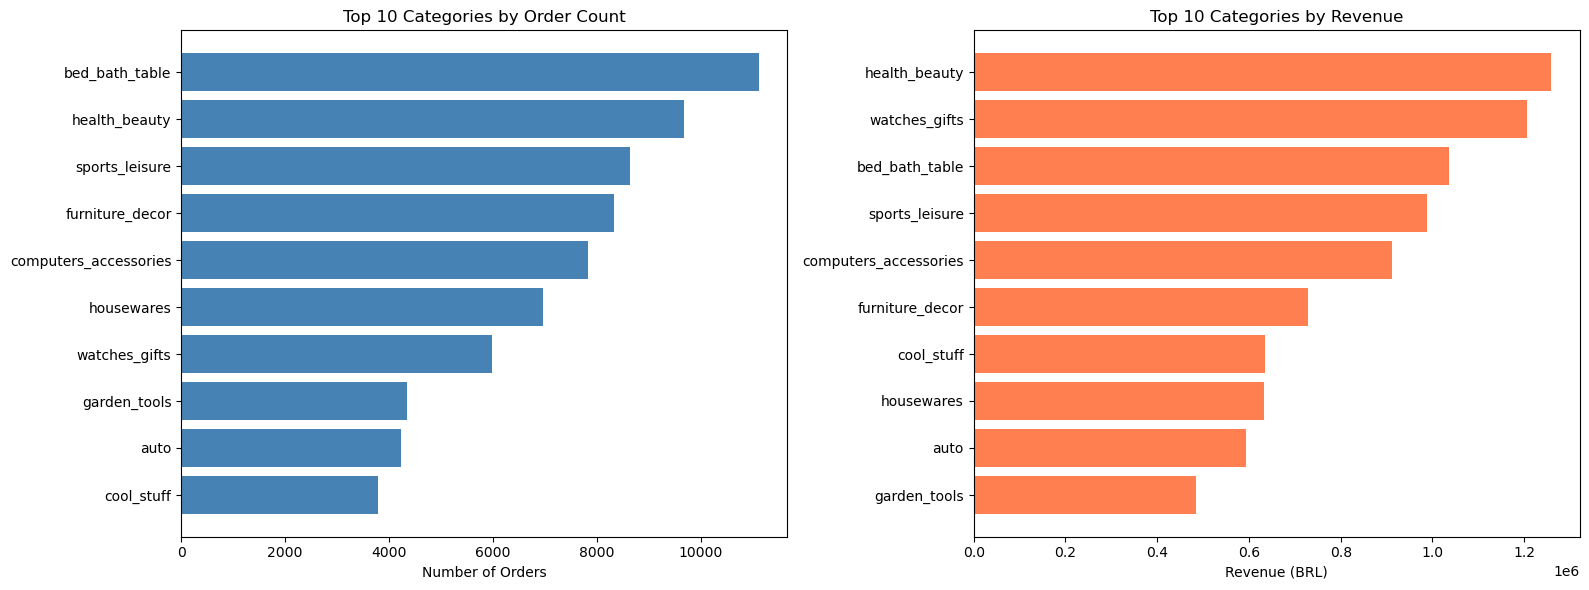

In [27]:
# Yatay bar grafik — kategori isimleri uzun olduğu için yatay daha okunabilir
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Sipariş sayısına göre sıralı
top10_orders = top10.sort_values('total_orders')
ax1.barh(top10_orders['product_category_name_english'], 
         top10_orders['total_orders'], color='steelblue')
ax1.set_title('Top 10 Categories by Order Count')
ax1.set_xlabel('Number of Orders')

# Sağ: Gelire göre sıralı
top10_revenue = top10.sort_values('total_revenue')
ax2.barh(top10_revenue['product_category_name_english'], 
         top10_revenue['total_revenue'], color='coral')
ax2.set_title('Top 10 Categories by Revenue')
ax2.set_xlabel('Revenue (BRL)')

plt.tight_layout()
plt.show()

In [28]:
# Ortalama ürün fiyatını hesapla
# total_revenue / total_orders = ortalama birim fiyat
top10['avg_order_value'] = top10['total_revenue'] / top10['total_orders']

# Ortalama değere göre sırala
print(top10[['product_category_name_english', 'avg_order_value']]
      .sort_values('avg_order_value', ascending=False))

   product_category_name_english  avg_order_value
70                 watches_gifts       201.135984
20                    cool_stuff       167.357969
5                           auto       139.957523
43                 health_beauty       130.163531
15         computers_accessories       116.513903
65                sports_leisure       114.344285
42                  garden_tools       111.630196
7                 bed_bath_table        93.296327
49                    housewares        90.788148
39               furniture_decor        87.564494


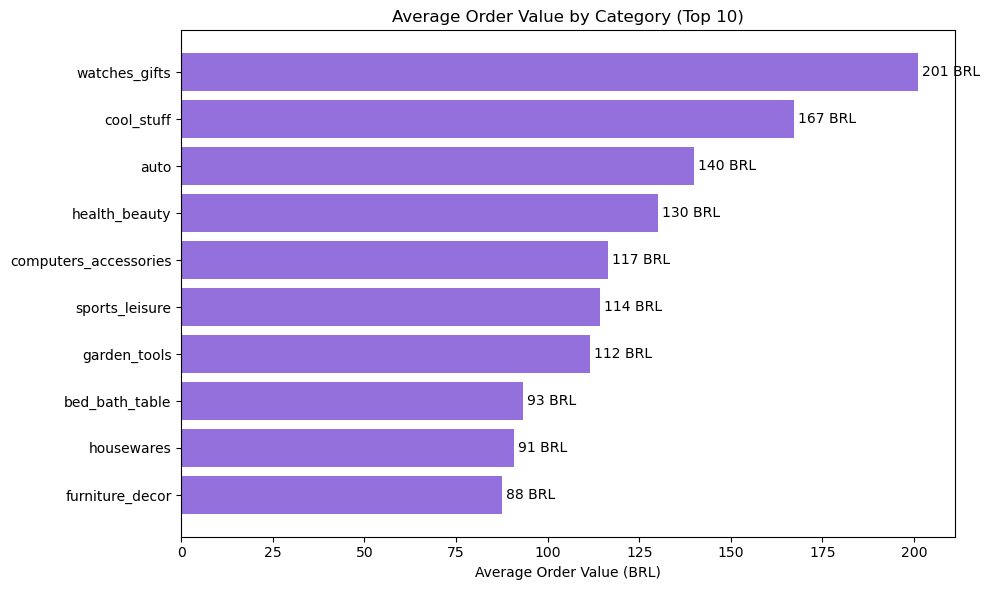

In [29]:
# Ortalama sipariş değerini büyükten küçüğe sırala
top10_avg = top10.sort_values('avg_order_value', ascending=True)

plt.figure(figsize=(10, 6))

# renk skalası — değer yükseldikçe renk koyulaşsın
plt.barh(top10_avg['product_category_name_english'], 
         top10_avg['avg_order_value'], 
         color='mediumpurple')

# Her barın ucuna değeri yaz
for i, v in enumerate(top10_avg['avg_order_value']):
    plt.text(v + 1, i, f'{v:.0f} BRL', va='center')

plt.title('Average Order Value by Category (Top 10)')
plt.xlabel('Average Order Value (BRL)')
plt.tight_layout()
plt.show()

In [30]:
# Teslimat süresi hesapla
# Sipariş tarihinden teslimata kadar kaç gün geçmiş?
orders_delivered['delivery_days'] = (
    pd.to_datetime(orders_delivered['order_delivered_customer_date']) - 
    pd.to_datetime(orders_delivered['order_purchase_timestamp'])
).dt.days

# Tahmini teslimat ile gerçek teslimat farkı
# Negatif = erken, Pozitif = geç
orders_delivered['delivery_delay'] = (
    pd.to_datetime(orders_delivered['order_delivered_customer_date']) - 
    pd.to_datetime(orders_delivered['order_estimated_delivery_date'])
).dt.days

print("Ortalama teslimat süresi:", orders_delivered['delivery_days'].mean().round(1), "gün")
print("Ortalama gecikme:", orders_delivered['delivery_delay'].mean().round(1), "gün")
print("Geç teslimat oranı:", 
      (orders_delivered['delivery_delay'] > 0).sum() / len(orders_delivered) * 100, "%")

Ortalama teslimat süresi: 12.1 gün
Ortalama gecikme: -11.9 gün
Geç teslimat oranı: 6.77252845208234 %


/var/folders/72/kv9nywss4pv1gl37mpt0p1nc0000gn/T/ipykernel_10507/3524216752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_delivered['delivery_days'] = (
/var/folders/72/kv9nywss4pv1gl37mpt0p1nc0000gn/T/ipykernel_10507/3524216752.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_delivered['delivery_delay'] = (


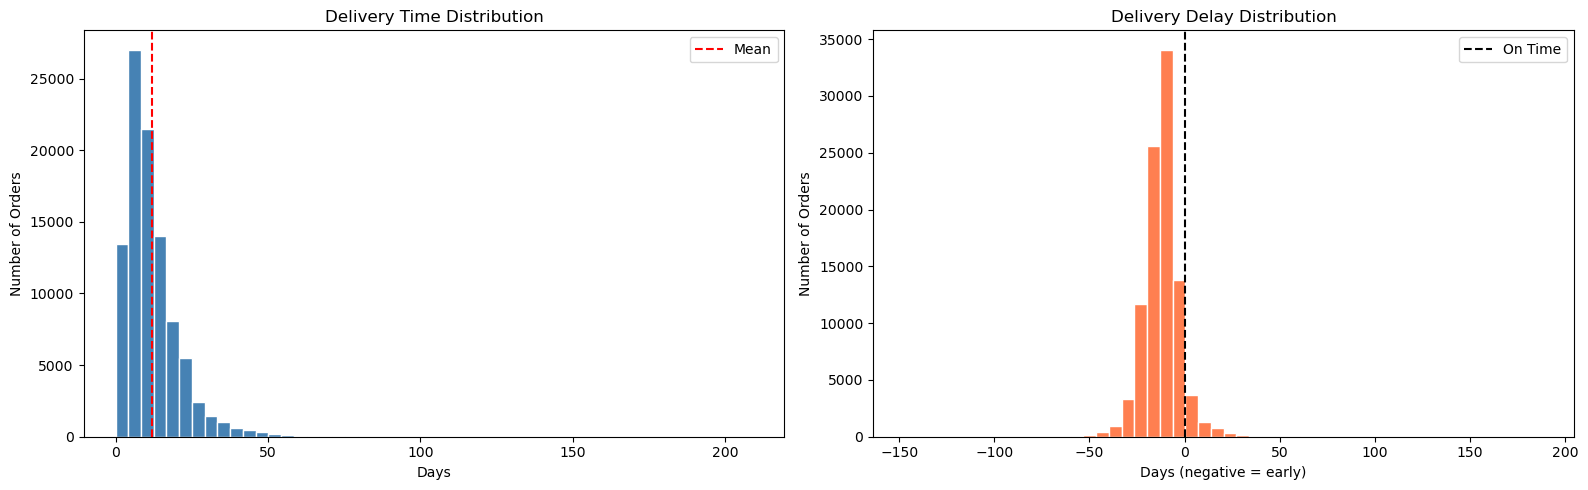

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Sol: Teslimat süresi dağılımı
# hist() → histogram, değerlerin dağılımını gösterir
# bins=50 → kaç sütuna böleceğimizi belirler
ax1.hist(orders_delivered['delivery_days'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax1.set_title('Delivery Time Distribution')
ax1.set_xlabel('Days')
ax1.set_ylabel('Number of Orders')
ax1.axvline(orders_delivered['delivery_days'].mean(), color='red', linestyle='--', label='Mean')
ax1.legend()

# Sağ: Gecikme dağılımı
# axvline → dikey çizgi çizer, 0 = zamanında teslim sınırı
ax2.hist(orders_delivered['delivery_delay'].dropna(), bins=50, color='coral', edgecolor='white')
ax2.set_title('Delivery Delay Distribution')
ax2.set_xlabel('Days (negative = early)')
ax2.set_ylabel('Number of Orders')
ax2.axvline(0, color='black', linestyle='--', label='On Time')
ax2.legend()

plt.tight_layout()
plt.show()